# Verification: `egfr_oligomerization_mitra2019`

Network-free EGFR higher-order-oligomerization model of **Mitra et al. (2019)**,
*iScience* 19:1012-1036 (doi:10.1016/j.isci.2019.08.045; BioNetFit-1 "example 2"),
fit to the cluster-density and phospho-EGFR data of **Kozer et al. (2013)**,
*Mol BioSyst* 9:1849-1863 (doi:10.1039/c3mb70073a). EGF drives EGFR into
ectodomain-crosslinked oligomers that grow without bound, so the model is simulated
**network-free** (NFsim / RuleMonkey). This is genuine multivalent **aggregation**:
the bimolecular crosslink rules join two *separate* aggregates while ring closure is
the dedicated `chi_r`-enhanced rules, so the crosslink rules block same-complex
binding (NFsim `-bscb`; the 4-molecule ring patterns also need `-utl 5`).

> **Provenance.** This is the Mitra 2019 network-free reformulation of the Kozer 2013
> model, *not* the Kozer 2014 SI (a tetramer-capped ODE model with Grb2). See
> `pybnf-jobs/Kozer-2013/egfr_nf/VALIDATION.md`.

Two levels of verification (issue #8), both driven by
[`run_mitra2019.py`](run_mitra2019.py):

1. **Reported-data check** — the model (`-bscb -utl 5`) at the PyBioNetFit best fit
   reproduces the Kozer 2013 **Fig 2B/2D** (dose-response) and **Fig 3B/3D**
   (time-course) cluster-density and phospho-EGFR data.
2. **Independent-algorithm check** (capability group) — because legacy NFsim is not a
   self-evidently valid reference for an aggregation model, correctness is confirmed
   by agreement of the two *independent* network-free algorithms bngsim provides,
   **NFsim** (Yang et al. 2008) and the exact **RuleMonkey** (Colvin et al.
   2009/2010), both with `-bscb`. BNG2.pl's bundled **legacy NFsim v1.14.3** binary is
   shown for contrast: it reads ~12% lower on pEGFR (a binary-version difference, *not*
   the traversal limit) — exactly why legacy NFsim is not the reference here. A
   no-`bscb` run is also shown; at this fit it differs from `-bscb` by only a few
   percent, because higher-order rings are only rarely populated.

This notebook loads the committed reference data (`reference/*.npz`) and displays the
results. To regenerate everything (needs `BNGPATH` set and the `bngsim` package):

```bash
python run_mitra2019.py all      # reference + agreement + plot
```

In [1]:
import os
import numpy as np

HERE = os.getcwd()
REF = os.path.join(HERE, "reference")

# 1) Reported-data check: Kozer 2013 Fig 2B/2D/3B/3D reproduction (NFsim -bscb, best fit).
rp = np.load(os.path.join(REF, "reproduction.npz"))


def _metrics(model, data, sd):
    ok = ~np.isnan(data)
    chisq = 0.5 * float(np.sum(((model[ok] - data[ok]) / sd[ok]) ** 2))
    big = ok & (np.abs(data) > 0.05)
    rel = np.abs(model[big] - data[big]) / np.abs(data[big])
    return chisq, float(np.median(rel))


rows = [
    ("Fig 3B cluster density (time)", rp["m_pre2"], rp["d_pre2"], rp["d_pre2_sd"]),
    ("Fig 3D phospho-EGFR   (time)", rp["m_pre4"], rp["d_pre4"], rp["d_pre4_sd"]),
    ("Fig 2B cluster density (dose)", rp["m_pre1"], rp["d_pre1"], rp["d_pre1_sd"]),
    ("Fig 2D phospho-EGFR   (dose)", rp["m_pre3"], rp["d_pre3"], rp["d_pre3_sd"]),
]
print(f"Kozer 2013 reproduction (NFsim -bscb, PyBNF best fit, {int(rp['n_reps'])} replicates):")
print(f"  {'dataset':32s} {'chi_sq':>8s} {'median|rel err|':>16s}")
total = 0.0
for lab, m, d, sd in rows:
    chisq, med = _metrics(m, d, sd)
    total += chisq
    print(f"  {lab:32s} {chisq:8.2f} {med:16.3f}")
print(f"  {'TOTAL chi_sq':32s} {total:8.2f}   (published PyBNF best fit chi_sq = 13.4)")
assert total < 30.0, "reproduction chi_sq should be near the published best fit"
print("  -> PASS: reproduces Kozer 2013 Fig 2B/2D/3B/3D at the published fit quality")

Kozer 2013 reproduction (NFsim -bscb, PyBNF best fit, 4 replicates):
  dataset                            chi_sq  median|rel err|
  Fig 3B cluster density (time)        3.23            0.136
  Fig 3D phospho-EGFR   (time)         5.80            0.063
  Fig 2B cluster density (dose)        2.41            0.092
  Fig 2D phospho-EGFR   (dose)         3.47            0.117
  TOTAL chi_sq                        14.91   (published PyBNF best fit chi_sq = 13.4)
  -> PASS: reproduces Kozer 2013 Fig 2B/2D/3B/3D at the published fit quality


In [2]:
# 2) Independent-algorithm check (capability group). The two INDEPENDENT network-free
#    algorithms bngsim provides -- NFsim (Yang 2008) and the exact RuleMonkey (Colvin
#    2009/2010), both -bscb -- are the reference of record. BNG2.pl's bundled LEGACY
#    NFsim v1.14.3 binary is shown for contrast.
ag = np.load(os.path.join(REF, "agreement.npz"))
doses = ag["doses"]

labels = [("bngsim_nf", "bngsim NFsim"), ("bngsim_rm", "RuleMonkey (exact)"),
          ("bng_nf", "legacy v1.14.3")]
print(f"per-dose equilibrium pEGFR (mean +/- s.e.m.), {int(ag['n_seeds'])} seeds/engine:")
print("  dose(nM)  " + "  ".join(f"{n:>20s}" for _, n in labels))
for i in range(len(doses)):
    cells_ = []
    for k, _ in labels:
        A = ag[f"pe_{k}"]
        m, se = A[:, i].mean(), A[:, i].std(ddof=1) / np.sqrt(A.shape[0])
        cells_.append(f"{m:.0f}+/-{se:.0f}")
    print(f"  {doses[i]:8.3f}  " + "  ".join(f"{c:>20s}" for c in cells_))

rel_pe, rel_cl, legacy = float(ag["rel_pe"]), float(ag["rel_cl"]), float(ag["legacy_pe"])
print(f"\nPRIMARY: bngsim NFsim == bngsim RuleMonkey (two independent NF algorithms),")
print(f"  max relative diff (informative doses): pEGFR = {rel_pe:.1%}, Clusters = {rel_cl:.1%}")
assert rel_pe < 0.10 and rel_cl < 0.10, "the two independent NF algorithms should agree"
print(f"legacy BNG2.pl NFsim v1.14.3 vs exact RuleMonkey: pEGFR offset {legacy:.0%} "
      f"(binary-version\n  difference, NOT the traversal limit -- utl 4/5/6 give the same "
      f"means)")

# Contrast: dropping -bscb (same bngsim NFsim engine).
on = ag["pe_bngsim_nf"].mean(0)
off = ag["pe_bngsim_nf_nobscb"].mean(0)
print(f"-bscb vs no-bscb (bngsim NFsim): max |d pEGFR| = {np.abs(on - off).max():.1f} "
      f"molecules")
print("  -> PASS: bngsim NFsim = RuleMonkey with -bscb (the reference of record); legacy\n"
      "     NFsim v1.14.3 reads lower, so it is NOT the reference for this aggregation\n"
      "     model. -bscb and no-bscb differ by only a few percent here (higher-order\n"
      "     rings only rarely populated at this fit, unlike a ring-forming model like TLBR).")

per-dose equilibrium pEGFR (mean +/- s.e.m.), 6 seeds/engine:
  dose(nM)          bngsim NFsim    RuleMonkey (exact)        legacy v1.14.3
     0.100                 5+/-2                 6+/-1                 4+/-1
     1.000               311+/-5               317+/-8               280+/-3
    10.000               392+/-4              386+/-10               364+/-7

PRIMARY: bngsim NFsim == bngsim RuleMonkey (two independent NF algorithms),
  max relative diff (informative doses): pEGFR = 1.8%, Clusters = 0.9%
legacy BNG2.pl NFsim v1.14.3 vs exact RuleMonkey: pEGFR offset 12% (binary-version
  difference, NOT the traversal limit -- utl 4/5/6 give the same means)
-bscb vs no-bscb (bngsim NFsim): max |d pEGFR| = 16.8 molecules
  -> PASS: bngsim NFsim = RuleMonkey with -bscb (the reference of record); legacy
     NFsim v1.14.3 reads lower, so it is NOT the reference for this aggregation
     model. -bscb and no-bscb differ by only a few percent here (higher-order
     rings only rarely 

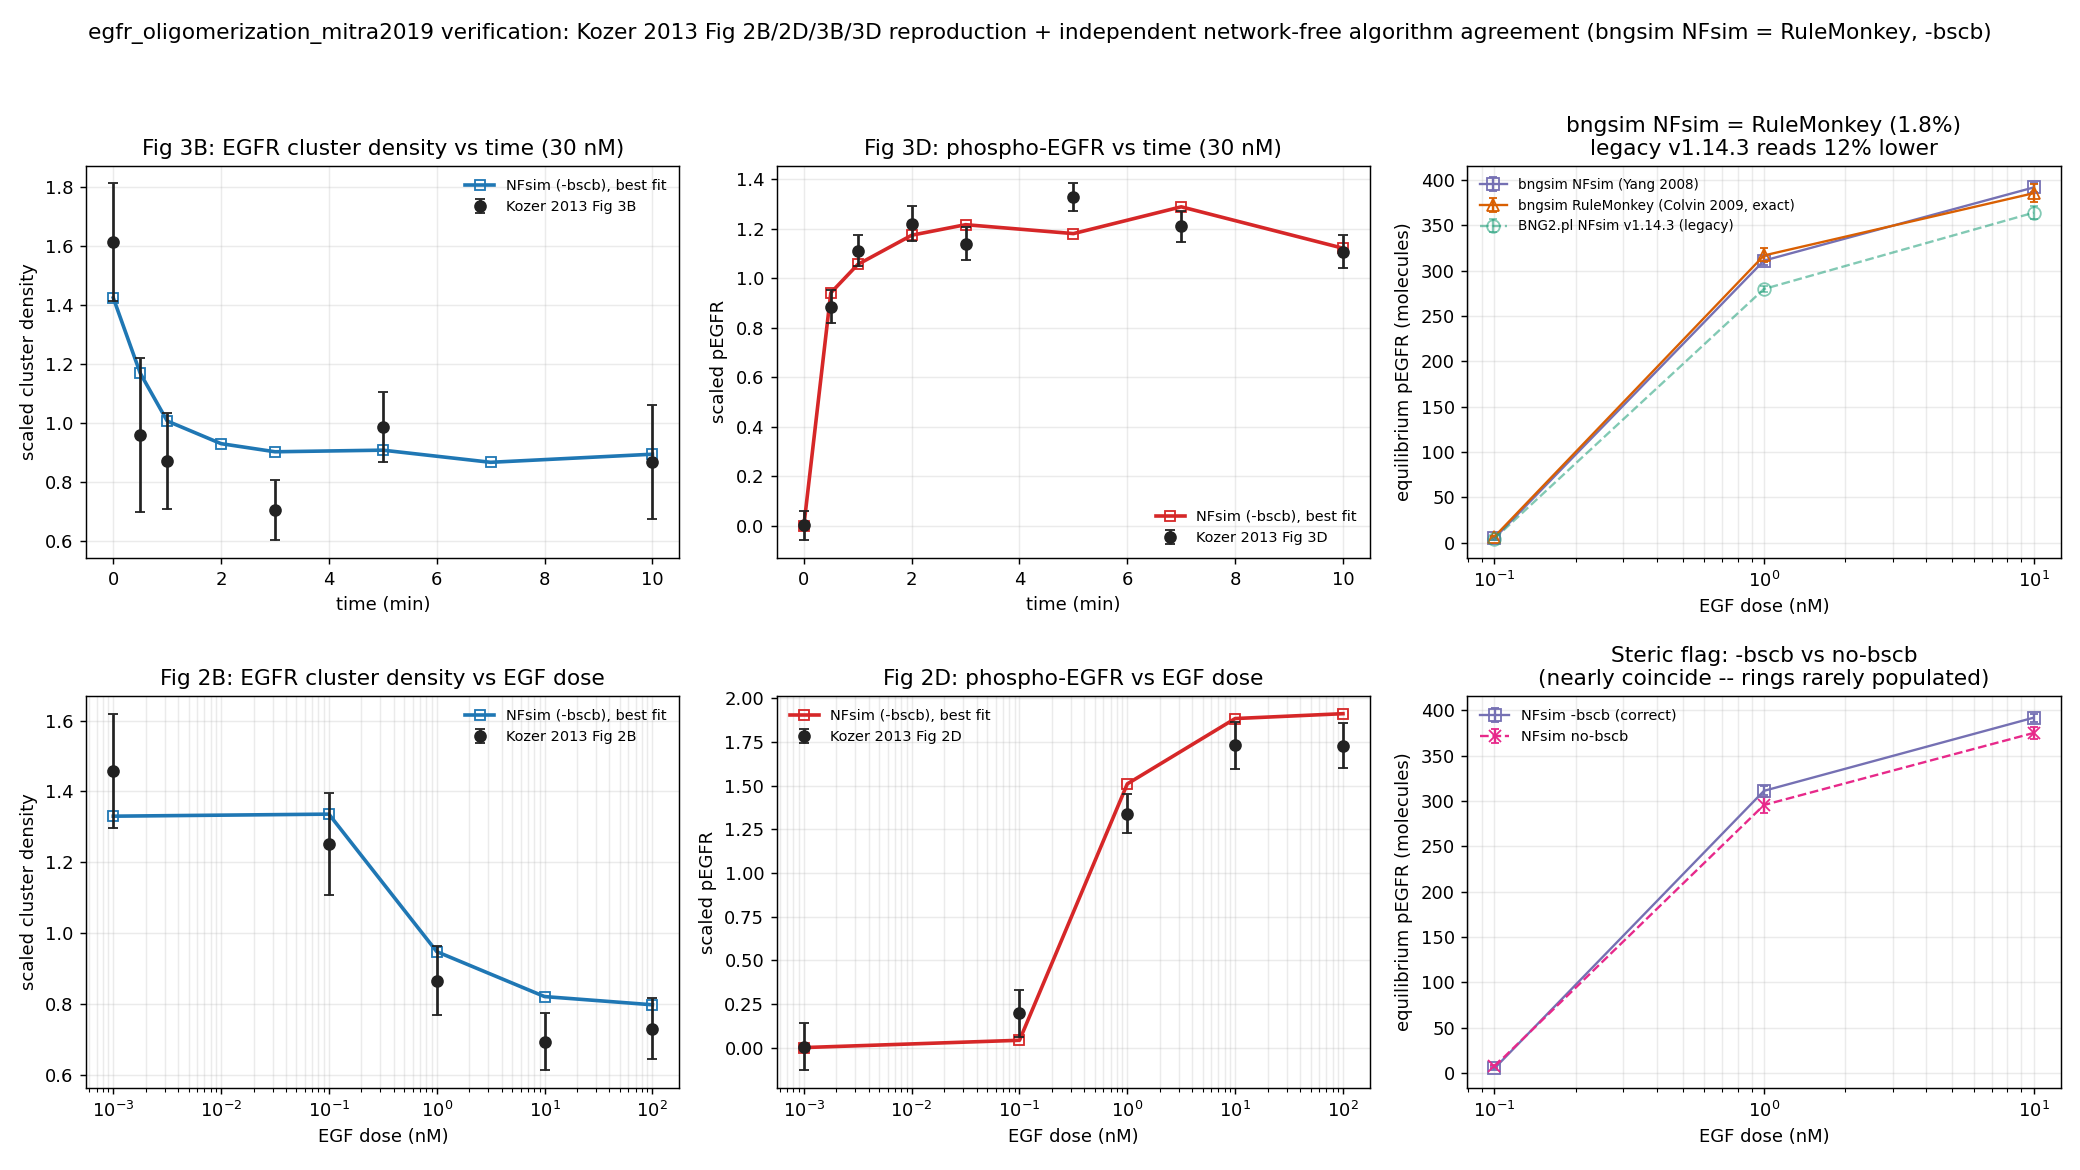

In [3]:
# Verification figure (built by run_mitra2019.py plot).
from IPython.display import Image
Image(filename=os.path.join(HERE, "verify_mitra2019.png"))